In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
x = df.drop('HeartDisease',axis = 'columns')
y = df['HeartDisease']

In [6]:
le_Sex = LabelEncoder()
le_ChestPainType = LabelEncoder()
le_RestingECG = LabelEncoder()
le_ExerciseAngina = LabelEncoder()
le_ST_Slope = LabelEncoder()
x['Sex_n'] = le_Sex.fit_transform(x['Sex'])
x['ChestPainType_n'] = le_ChestPainType.fit_transform(x['ChestPainType'])
x['RestingECG_n'] = le_RestingECG.fit_transform(x['RestingECG'])
x['ExerciseAngina_n'] = le_ExerciseAngina.fit_transform(x['ExerciseAngina'])
x['ST_Slope_n'] = le_ST_Slope.fit_transform(x['ST_Slope'])

In [8]:
x.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Sex_n,ChestPainType_n,RestingECG_n,ExerciseAngina_n,ST_Slope_n
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,1,1,1,0,2
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,0,2,1,0,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,1,1,2,0,2
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,0,0,1,1,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,1,2,1,0,2


In [9]:
X = x.drop(['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope'],axis = 'columns')
X

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_n,ChestPainType_n,RestingECG_n,ExerciseAngina_n,ST_Slope_n
0,40,140,289,0,172,0.0,1,1,1,0,2
1,49,160,180,0,156,1.0,0,2,1,0,1
2,37,130,283,0,98,0.0,1,1,2,0,2
3,48,138,214,0,108,1.5,0,0,1,1,1
4,54,150,195,0,122,0.0,1,2,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,3,1,0,1
914,68,144,193,1,141,3.4,1,0,1,0,1
915,57,130,131,0,115,1.2,1,0,1,1,1
916,57,130,236,0,174,0.0,0,1,0,0,1


In [12]:
X_train,X_test,y_train,y_test = train_test_split(X.values,y,
                                                 test_size = 0.2,
                                                random_state = 20)

In [13]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

734
184
734
184


In [14]:
model = RandomForestClassifier(n_estimators = 90)
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.875

In [15]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0])

In [16]:
y_test.values

array([1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1])

In [17]:
accuracy_score(y_test,y_pred)

0.875

In [18]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[70, 15],
       [ 8, 91]])

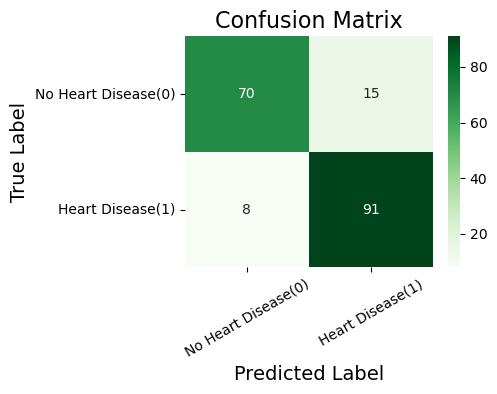

In [19]:
plt.figure(figsize = (4,3))
g = sns.heatmap(cm,cmap = 'Greens',annot = True)
g.set_xticklabels(labels = ['No Heart Disease(0)','Heart Disease(1)'],rotation=30)
g.set_yticklabels(labels = ['No Heart Disease(0)','Heart Disease(1)'],rotation=0)
plt.ylabel('True Label',fontsize = 14)
plt.xlabel('Predicted Label',fontsize = 14)
plt.title('Confusion Matrix',fontsize = 16)
plt.show()

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        85
           1       0.86      0.92      0.89        99

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184



In [21]:
model.predict([[37,130,283,0,98,0.0,1,1,2,0,2]])

array([0])

In [22]:
if model.predict([[37,130,283,0,98,0.0,1,1,2,0,2]])[0]==1:
    print("Having Heart Disease")
else:
    print("Not Having Heart Disease")

Not Having Heart Disease
